In [2]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import py_files.fig_setup as fs
importlib.reload(fs)     
fs.set_aej()          

# *LR* `capital` market equilibrium

**Intention:** In the below, I reproduce `Figure 1`from (Gouin-Bonenfant and Gomez, 2025), showing the demand- and supply elasticities of capital and their intersection.

**Model Overview:** The model is given centrally by
\begin{align*}
    C &= K_C^\alpha L_C^{1-\alpha}, \tag{Consumption good sector}   \\
    I &= K_I^\beta L_I^{1-\beta},   \tag{Investment good sector}    \\
    K'&= (1-\delta)K + I,           \tag{Law of motion}             \\
    r &= \frac{r_K}{q} - \delta     \tag{Arbitrage condition}
\end{align*}
This yields the steady state elasticities in the long run:
\begin{align*}
    \frac{\partial \log K^s}{\partial \log q}&= \frac{1}{\alpha-\beta}
     + \frac{1}{\alpha-\beta}\frac{\delta(1-\beta)}{(1-\alpha)r+\delta(1-\beta)}, \tag{Supply elasticity}\\
     \frac{\partial \log K^d}{\partial \log q}&=-\frac{1}{1-\alpha}-\frac{(1-\beta)\delta}{(1-\alpha)r+\delta(1-\beta)}
        \tag{Demand elasticity}
\end{align*}
Around this steady state vealues, the demand and syupply curves can be represented as
\begin{gather*}
    q(K^d)= q^* \left(\frac{K^d}{K^*} \right)^\frac{1}{\varepsilon^d}, \\
    q(K^s) = q^* \left(\frac{K^s}{K^*}\right)^\frac{1}{\varepsilon^s}, \\
    K^* = \left( \frac{1}{\delta} s_K^\beta s_L^{1-\beta} \right)^\frac{1}{1-\beta} ,\quad
    q^* = \frac{\alpha\left( \frac{1-s_L}{1-s_K}\right)^{1-\alpha} }{\beta \left( \frac{s_L}{s_K}\right)^{1-\beta}} (K^*)^{\alpha-\beta}, \quad 
    s_L = \frac{\alpha(1-\beta)s_K}{\beta(1-\alpha)+s_K(\alpha - \beta)}, \quad
    s_K = \beta\frac{\delta}{r+\delta}.
\end{gather*}

### 1. Plotting the general case

In [3]:
# 1. steady state values
def compute_ss(alpha, beta, delta, r):
    s_K = beta * delta / (r+delta)
    s_L = alpha * (1-beta) * s_K / (beta*(1-alpha) + s_K*(alpha-beta))
    K_star = (1/delta * s_K**beta * s_L**(1-beta))**(1/(1-beta))
    q_star = alpha * ((1-s_L)/(1-s_K))**(1-alpha) / (beta * (s_L/s_K)**(1-beta)) * K_star**(alpha-beta)
    
    return s_K, s_L, K_star, q_star

# 2. elasticities
def compute_elas(alpha, beta, delta, r):
    supply_elas = 1/(alpha-beta) - delta*(1-beta) / ((1-alpha)*r + delta*(1-beta))
    demand_elas = -1/(1-alpha) - (1-beta)*delta / ((1-alpha)*r + delta*(1-beta))
    
    return supply_elas, demand_elas

# 3. curves
def cap_demand_price(K):
        q = q_star * (K/K_star)**(1/demand_elas)
        return q
    
def cap_demand_price_tax(K, tau, tau_star):
        q = q_star * (K/K_star)**(1/demand_elas) * ( (1-tau)/(1-tau_star) )**( -1 /((1-alpha)*demand_elas) )
        return q

def cap_supply_price(K):
        q = q_star * (K/K_star)**(1/supply_elas)
        return q

*Plot*

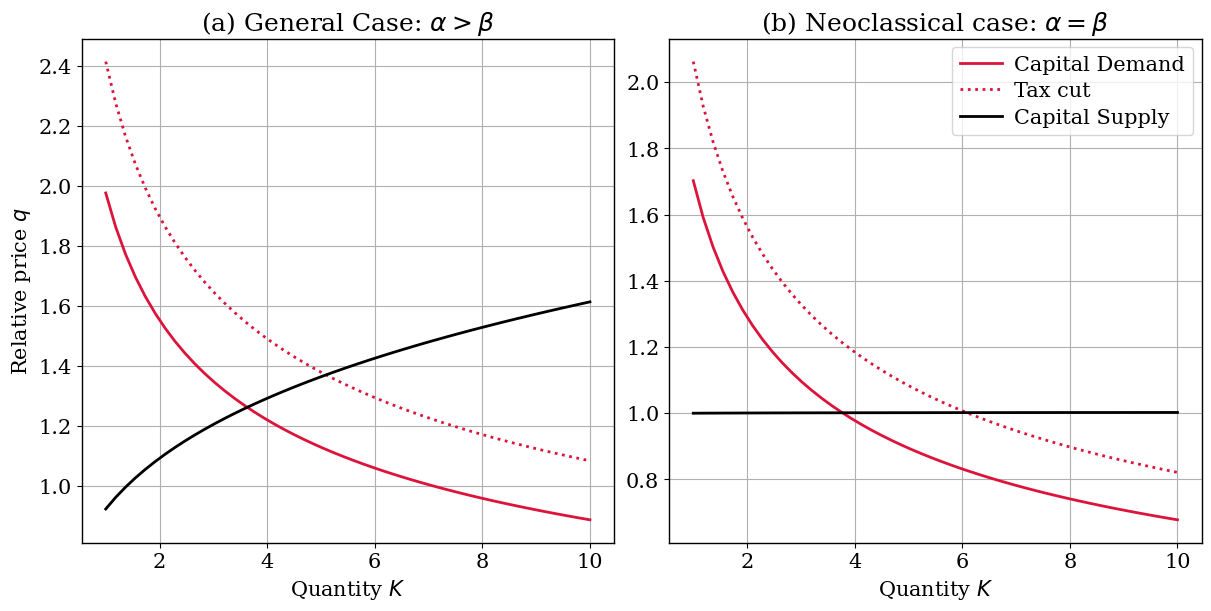

In [4]:
# 1. values
K_grid = np.linspace(1, 10, 50)

# 2. general case
alpha, beta, delta, r, tau, tau_star = 0.5, 0.3, 0.15, 0.03, 0.2, 0.4

s_K, s_L, K_star, q_star = compute_ss(alpha, beta, delta, r)
supply_elas, demand_elas = compute_elas(alpha, beta, delta, r)
q_grid_g1_b = cap_demand_price(K_grid)
q_grid_g1_s = cap_demand_price_tax(K_grid, tau=tau, tau_star=tau_star)
q_grid_q2 = cap_supply_price(K_grid)

# 3. alpha equal beta
alpha, beta, delta, r, tau = 0.4, 0.399, 0.15, 0.03, 0.2

s_K, s_L, K_star, q_star = compute_ss(alpha, beta, delta, r)
supply_elas, demand_elas = compute_elas(alpha, beta, delta, r)
q_grid_nc1_b = cap_demand_price(K_grid)
q_grid_nc1_s = cap_demand_price_tax(K_grid, tau=tau, tau_star=tau_star)
q_grid_nc2 = cap_supply_price(K_grid)

# 4. plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharex=True, constrained_layout=True)

# 4.1 general case
ax[0].plot(K_grid, q_grid_g1_b, label='Capital Demand', color='crimson', lw=2)
ax[0].plot(K_grid, q_grid_g1_s, label='Tax cut', color='crimson', linestyle=':', lw=2)
ax[0].plot(K_grid, q_grid_q2, label='Capital Supply', color='k', lw=2)
ax[0].set_xlabel(r'Quantity $K$')
ax[0].set_ylabel(r'Relative price $q$')
ax[0].set_title(r'(a) General Case: $\alpha > \beta$')
ax[0].grid(True)

# 4.2 alpha equal beta
ax[1].plot(K_grid, q_grid_nc1_b, label='Capital Demand', color='crimson', lw=2)
ax[1].plot(K_grid, q_grid_nc1_s, label='Tax cut', color='crimson', linestyle=':', lw=2)
ax[1].plot(K_grid, q_grid_nc2, label='Capital Supply', color='k', lw=2)
ax[1].set_xlabel(r'Quantity $K$')
# ax[1].set_ylabel(r'Relative price $q$')
ax[1].set_title(r'(b) Neoclassical case: $\alpha = \beta$')
ax[1].legend()
ax[1].grid(True)

*Print*

In [5]:
print('===== Genera case =====')
alpha, beta, delta, r, tau, tau_star = 0.36, 0.26, 0.15, 0.07, 0.2, 0.4
supply_elas, demand_elas = compute_elas(alpha, beta, delta, r)
print('Using the papers calibration parameters, I get:')
print(f'A demand elasticity of {demand_elas:.3f} and supply elasticity: {supply_elas:.3f} (paper has 9.2)')

print('\n ===== Neoclassical case =====')
alpha, beta, delta, r, tau, tau_star = 0.36, 0.359, 0.15, 0.07, 0.2, 0.4
supply_elas, demand_elas = compute_elas(alpha, beta, delta, r)
print('Keeping all parameters the same but setting alpha = beta = 0.36, I get:')
print(f'A demand elasticity of {demand_elas:.3f} and supply elasticity: {supply_elas:.3f}')

===== Genera case =====
Using the papers calibration parameters, I get:
A demand elasticity of -2.275 and supply elasticity: 9.288 (paper has 9.2)

 ===== Neoclassical case =====
Keeping all parameters the same but setting alpha = beta = 0.36, I get:
A demand elasticity of -2.245 and supply elasticity: 999.318
